# Overnight Return Anomaly in U.S. Equity Markets

This project explores the overnight return anomaly: the observation that a large portion of equity-market returns may occur between the previous trading day's close and the next day's open rather than during regular trading hours.

We will compare overnight, intraday, and buy-and-hold returns across major U.S. equity ETFs, with a focus on performance, risk, statistical significance, and consistency over time.

## Main findings

- About **81.95% of SPY's cumulative log price return** occurred overnight. Buy-and-hold still finished with more wealth than overnight-only.
- Overnight-only had a higher historical Sharpe ratio and a smaller maximum drawdown, but the daily mean overnight-minus-intraday difference was **not statistically significant** at the 5% level.
- The corrected **340-day EMA filter** improved the historical test-period Sharpe and drawdown, but finished with **0.93% less wealth** than overnight-only.

## Questions

1. How much of SPY's price return comes from overnight versus intraday returns?
2. Does an overnight-only strategy outperform buy-and-hold on a risk-adjusted basis?
3. Does the anomaly appear in other major equity ETFs?
4. Are mean overnight returns statistically different from mean intraday returns?
5. How sensitive is the anomaly to extreme observations?
6. Has the anomaly changed over time?
7. Can an EMA filter improve the overnight strategy?

## Data and interpretation

The main SPY analysis uses **unadjusted prices from January 3, 2000 through August 31, 2026**, so its returns exclude dividend income. The four-ETF comparison uses **adjusted prices beginning June 1, 2000**. Their date ranges and price bases differ, so the two sections should not be compared directly. Dividend adjustments can also affect the measured overnight return.

Growth means the value of an initial \$1; cumulative return is growth minus 1. Daily returns are stored as decimals, with 0.01 representing 1%. All SPY statistics use the same complete return dates, excluding the first row because it has no previous close. Annualization assumes 252 trading days, and both the risk-free rate and return on idle cash are set to zero. Transaction costs, slippage, taxes, and leverage financing are excluded.

### Running the notebook

Run the cells in order. Keep the supplied `data` folder beside this notebook and leave `use_saved_data = True` to reproduce these results. Set it to `False` to use the original Yahoo Finance download approach instead. The download end date is exclusive. The included `requirements.txt` records the packages used, and `data/provenance.json` describes the saved prices. If the data or parameters change, the written interpretations should be checked again.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.stats import ttest_rel, skew

# Use the same colors and basic style throughout.
overnight_color = "#2468A0"
intraday_color = "#B16B20"
benchmark_color = "#424B54"
filtered_color = "#68773D"

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.2,
})

In [2]:
start_date = "2000-01-01"
etf_start_date = "2000-06-01"
end_date = "2026-09-01"
train_end = "2017-12-31"
test_start = "2018-01-01"
trading_days = 252
ema_span = 340
use_saved_data = True

In [3]:
# Load the saved prices, or download the same date range.
if use_saved_data:
    spy = pd.read_csv("data/spy_unadjusted.csv", index_col=0, parse_dates=True)
else:
    spy = yf.download("SPY", start=start_date, end=end_date,
                      auto_adjust=False, progress=False)
    if isinstance(spy.columns, pd.MultiIndex):
        spy.columns = spy.columns.get_level_values(0)

spy.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2000-01-03,90.907005,145.4375,148.25000,143.875000,148.25000,8164300
2000-01-04,87.351997,139.7500,144.06250,139.640625,143.53125,8089800
2000-01-05,87.508224,140.0000,141.53125,137.250000,139.93750,12177900
2000-01-06,86.101883,137.7500,141.50000,137.750000,139.62500,6227200
2000-01-07,91.102333,145.7500,145.75000,140.062500,140.31250,8066500


In [4]:
spy.info()

# Check the prices before calculating returns; do not silently fill missing data.
assert not spy.empty
assert spy.index.is_unique and spy.index.is_monotonic_increasing
assert not spy[["Open", "Close"]].isna().any().any()
assert (spy[["Open", "Close"]] > 0).all().all()

<class 'pandas.DataFrame'>
DatetimeIndex: 6705 entries, 2000-01-03 to 2026-08-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  6705 non-null   float64
 1   Close      6705 non-null   float64
 2   High       6705 non-null   float64
 3   Low        6705 non-null   float64
 4   Open       6705 non-null   float64
 5   Volume     6705 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 366.7 KB


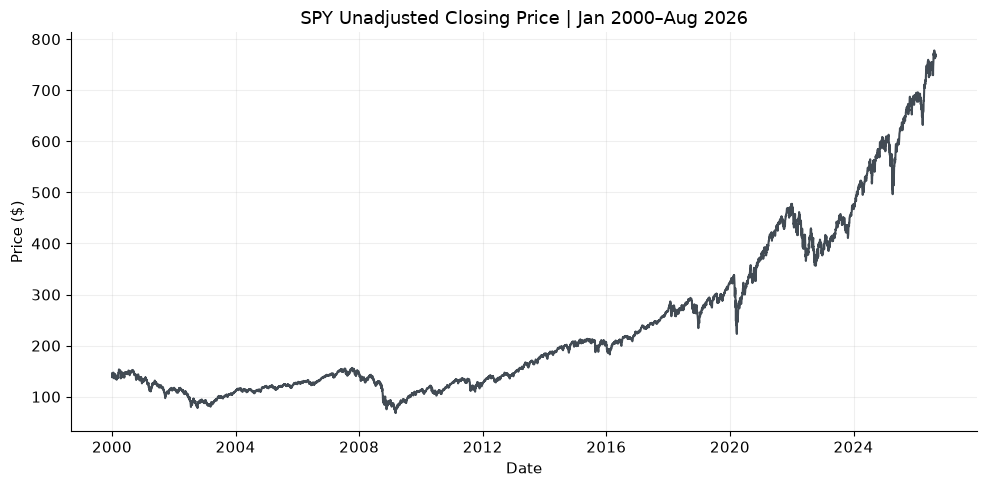

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(spy.index, spy["Close"], color=benchmark_color)
plt.title("SPY Unadjusted Closing Price | Jan 2000–Aug 2026")
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

Define $R$ to be return, $O_t$ to be market opening price, and $C_t$ to be market closing price. We will calculate returns using the following formulas:

$$
R_{\text{overnight}} = \frac{O_t}{C_{t-1}} - 1
$$

$$
R_{\text{intraday}} = \frac{C_t}{O_t} - 1 
$$

$$
R_{\text{daily}} = \frac{C_t}{C_{t-1}} - 1
$$

Here, $t-1$ means the previous trading day, so overnight returns also include weekends and market holidays. We will keep the price data in `spy`, the three aligned return series in `returns`, and their compounded wealth in `growth`. This avoids recalculating the same series under several names.

The relationship is multiplicative: $(1 + R_{\text{daily}}) = (1 + R_{\text{overnight}})(1 + R_{\text{intraday}})$.

In [6]:
spy["OvernightReturn"] = spy["Open"] / spy["Close"].shift(1) - 1
spy["IntradayReturn"] = spy["Close"] / spy["Open"] - 1
spy["DailyReturn"] = spy["Close"] / spy["Close"].shift(1) - 1

# Exclude the first day from every strategy's statistics so the dates match.
returns = spy[["OvernightReturn", "IntradayReturn", "DailyReturn"]].iloc[1:].copy()
assert not returns.isna().any().any()

## 1. How much of SPY's price return comes from overnight versus intraday returns?

First, we will look at SPY's cumulative price return. We will calculate the growth of all three strategies once and reuse it throughout the analysis. The first close is our starting point, with no first-day intraday trade.

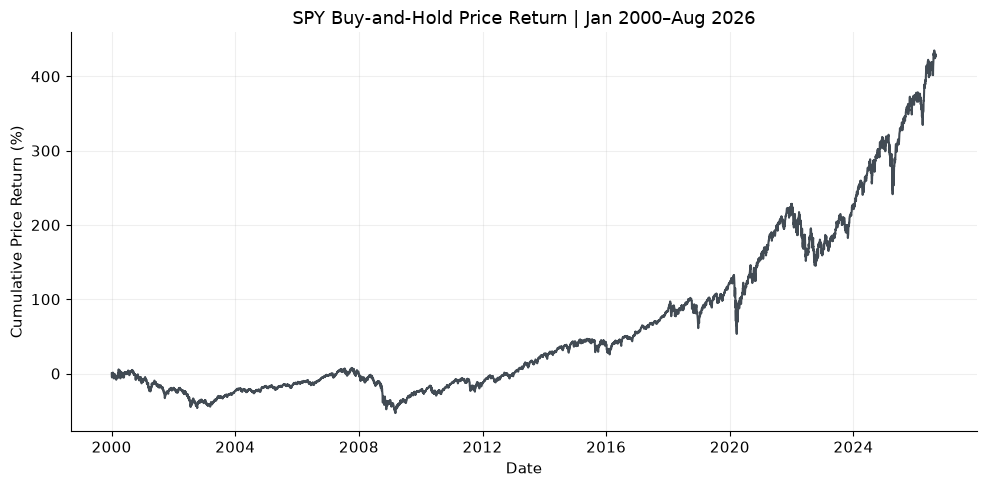

In [7]:
growth = (1 + returns).cumprod()
growth.loc[spy.index[0]] = 1  # Initial wealth before the first return.
growth = growth.sort_index()

plt.figure(figsize=(10, 5))
plt.plot(growth.index, (growth["DailyReturn"] - 1) * 100, color=benchmark_color)
plt.xlabel("Date")
plt.ylabel("Cumulative Price Return (%)")
plt.title("SPY Buy-and-Hold Price Return | Jan 2000–Aug 2026")
plt.tight_layout()
plt.show()

Now we will compare buy-and-hold with two simple strategies: holding only overnight and holding only intraday. All three use the same dates and starting point. The chart below shows cumulative returns, so each curve starts at zero.

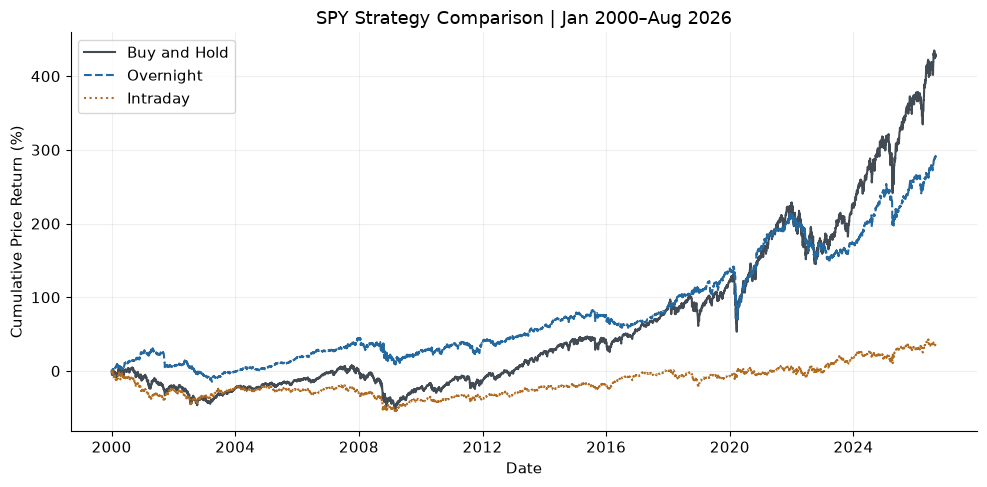

In [8]:
# Check that the overnight and intraday wealth curves reconcile to buy-and-hold.
np.testing.assert_allclose(
    growth["DailyReturn"],
    growth["OvernightReturn"] * growth["IntradayReturn"],
    rtol=1e-10,
)

plt.figure(figsize=(10, 5))
plt.plot(growth.index, (growth["DailyReturn"] - 1) * 100,
         label="Buy and Hold", color=benchmark_color)
plt.plot(growth.index, (growth["OvernightReturn"] - 1) * 100,
         label="Overnight", color=overnight_color, linestyle="--")
plt.plot(growth.index, (growth["IntradayReturn"] - 1) * 100,
         label="Intraday", color=intraday_color, linestyle=":")
plt.legend()
plt.title("SPY Strategy Comparison | Jan 2000–Aug 2026")
plt.xlabel("Date")
plt.ylabel("Cumulative Price Return (%)")
plt.tight_layout()
plt.show()

The benchmark and overnight strategies both show substantial growth, while the intraday strategy remains relatively flat for much of the sample. Overnight-only stays ahead of the benchmark during several earlier periods, but buy-and-hold eventually finishes with the highest cumulative return.

We will now measure how much of the benchmark's cumulative log return comes from each session. Log returns are useful here because they add across overnight and intraday periods; simple compounded returns do not.

In [9]:
log_returns = np.log1p(returns)
overnight_share = log_returns["OvernightReturn"].sum() / log_returns["DailyReturn"].sum()
intraday_share = log_returns["IntradayReturn"].sum() / log_returns["DailyReturn"].sum()

print(f"Overnight share of cumulative log return: {overnight_share:.2%}")
print(f"Intraday share of cumulative log return:  {intraday_share:.2%}")

Overnight share of cumulative log return: 81.95%
Intraday share of cumulative log return:  18.05%


Approximately **81.95% of SPY's cumulative log price return occurred overnight**, while **18.05% occurred intraday**. This shows that most of the sample's cumulative log return came from outside regular trading hours.

That does not mean overnight-only produced the most wealth. Buy-and-hold grew \$1 to about \$5.27, compared with \$3.91 overnight and \$1.35 intraday. The positive intraday contribution still helped buy-and-hold. We will next look at the risk taken to achieve those returns.

## 2. Does an overnight-only strategy outperform buy-and-hold on a risk-adjusted basis?

This section compares the strategies using the annualized Sharpe ratio and maximum drawdown. The Sharpe ratio measures mean return relative to return volatility. With daily returns and a zero risk-free rate, we calculate it as:

$$\text{Annualized Sharpe} = \sqrt{252}\,\frac{\bar{R}}{s_R}.$$

Here, $\bar{R}$ is the mean daily return and $s_R$ is its sample standard deviation. We will use the aligned daily returns, not the cumulative return curves.

In [10]:
annualized_sharpe = np.sqrt(trading_days) * returns.mean() / returns.std(ddof=1)
print(f"Annualized Sharpe overnight:    {annualized_sharpe['OvernightReturn']:.2f}")
print(f"Annualized Sharpe buy and hold: {annualized_sharpe['DailyReturn']:.2f}")

Annualized Sharpe overnight:    0.51
Annualized Sharpe buy and hold: 0.42


The overnight-only strategy has an annualized Sharpe ratio of **0.51**, compared with **0.42** for buy-and-hold, under the assumed zero risk-free rate. Overnight exposure therefore delivers a higher historical return per unit of daily return volatility, even though unlevered buy-and-hold finishes with greater cumulative wealth.

This is a descriptive comparison; the notebook does not test whether the Sharpe difference is statistically significant. We next examine hypothetical 2x exposure to see how leverage changes compounded performance. A higher unlevered Sharpe ratio does not imply that leverage avoids additional risk.

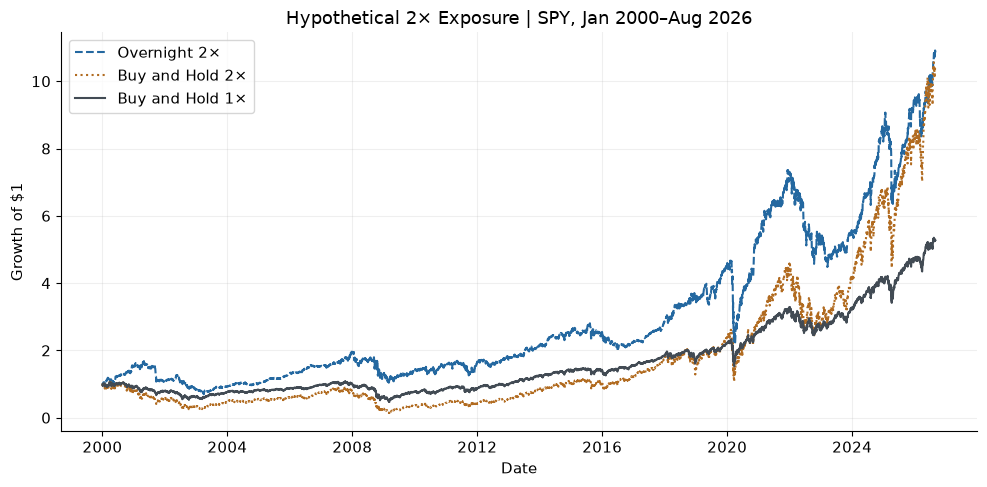

2× overnight has higher cumulative wealth on 6,685 dates (99.72%).


In [11]:
leveraged_growth = (1 + 2 * returns[["OvernightReturn", "DailyReturn"]]).cumprod()
leveraged_growth.loc[spy.index[0]] = 1
leveraged_growth = leveraged_growth.sort_index()

plt.figure(figsize=(10, 5))
plt.plot(leveraged_growth.index, leveraged_growth["OvernightReturn"],
         label="Overnight 2×", color=overnight_color, linestyle="--")
plt.plot(leveraged_growth.index, leveraged_growth["DailyReturn"],
         label="Buy and Hold 2×", color=intraday_color, linestyle=":")
plt.plot(growth.index, growth["DailyReturn"], label="Buy and Hold 1×", color=benchmark_color)
plt.title("Hypothetical 2× Exposure | SPY, Jan 2000–Aug 2026")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

# Exclude the initial baseline when counting return dates.
wealth_lead = (
    leveraged_growth.loc[returns.index, "OvernightReturn"] >
    leveraged_growth.loc[returns.index, "DailyReturn"]
)
print(f"2× overnight has higher cumulative wealth on {wealth_lead.sum():,} dates ({wealth_lead.mean():.2%}).")

The hypothetical 2× overnight strategy finishes above both 2× buy-and-hold and unlevered buy-and-hold. Its wealth curve is above the 2× buy-and-hold curve on **6,685 of 6,704 return dates**, or about **99.72%**. This is not a daily win rate; it compares accumulated wealth.

The calculation doubles each period's return before compounding and excludes financing costs, transaction costs, and margin constraints. It is a simplified daily-reset exposure scenario, not a simulation of a particular leveraged fund. We will keep this separate from the unlevered result, where buy-and-hold finishes ahead.

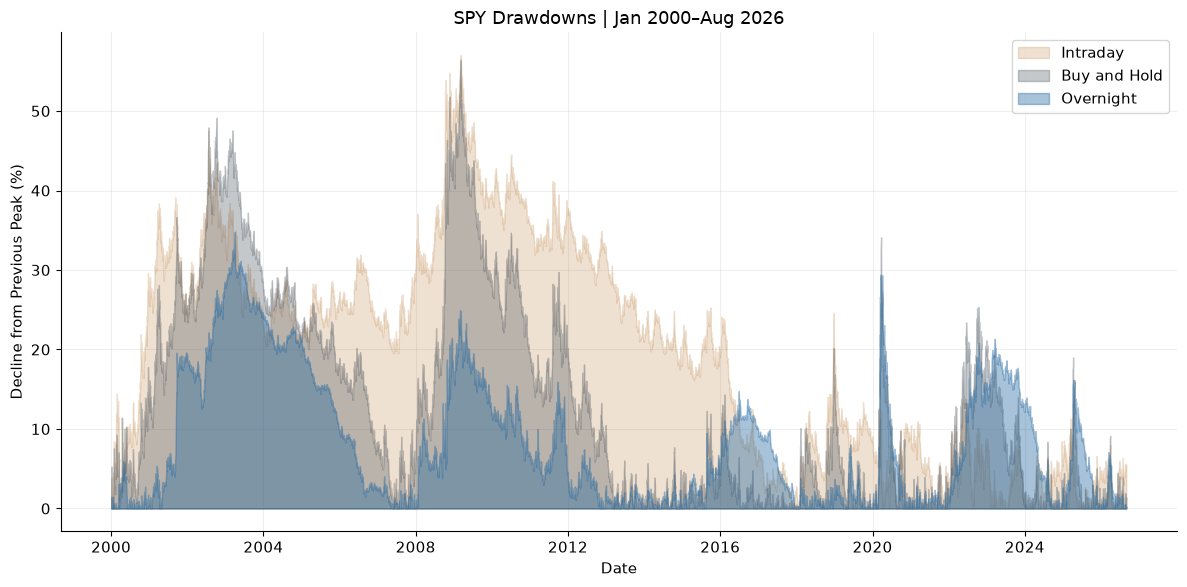

Overnight maximum drawdown:    34.76%
Buy-and-hold maximum drawdown: 56.47%
Intraday maximum drawdown:     57.04%
Difference: 21.71 percentage points


In [12]:
def drawdowns(growth_series):
    """Calculate the percentage decline from the previous wealth peak."""
    peaks = growth_series.cummax()
    return 1 - growth_series / peaks

# Reuse the existing wealth curves, including the initial $1.
overnight_drawdown = drawdowns(growth["OvernightReturn"])
benchmark_drawdown = drawdowns(growth["DailyReturn"])
intraday_drawdown = drawdowns(growth["IntradayReturn"])

plt.figure(figsize=(12, 6))
plt.fill_between(intraday_drawdown.index, intraday_drawdown * 100, 0,
                 alpha=0.2, label="Intraday", color=intraday_color)
plt.fill_between(benchmark_drawdown.index, benchmark_drawdown * 100, 0,
                 alpha=0.3, label="Buy and Hold", color=benchmark_color)
plt.fill_between(overnight_drawdown.index, overnight_drawdown * 100, 0,
                 alpha=0.4, label="Overnight", color=overnight_color)
plt.title("SPY Drawdowns | Jan 2000–Aug 2026")
plt.xlabel("Date")
plt.ylabel("Decline from Previous Peak (%)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Overnight maximum drawdown:    {overnight_drawdown.max():.2%}")
print(f"Buy-and-hold maximum drawdown: {benchmark_drawdown.max():.2%}")
print(f"Intraday maximum drawdown:     {intraday_drawdown.max():.2%}")
print(f"Difference: {(benchmark_drawdown.max() - overnight_drawdown.max()) * 100:.2f} percentage points")

Overnight-only has a maximum drawdown of **34.76%**, compared with **56.47%** for buy-and-hold, which is a difference of **21.71 percentage points**. This is a noticeable improvement in the historical risk profile, although overnight-only still experiences a substantial decline.

The three drawdown curves describe separate strategies. They are not additive pieces of the benchmark's drawdown, and their timing alone does not establish what caused the differences.

## 3. Does the anomaly appear in other major equity ETFs?

We will extend the comparison to QQQ, IWM, and DIA alongside SPY. This section uses adjusted prices and a common start date in June 2000. The goal is to see whether the overnight pattern is similar across these four ETFs, rather than assume the SPY result applies everywhere.

In [13]:
if use_saved_data:
    etf_data = pd.read_csv("data/etfs_adjusted.csv", header=[0, 1],
                           index_col=0, parse_dates=True)
else:
    etf_data = yf.download(["SPY", "QQQ", "IWM", "DIA"],
                           start=etf_start_date, end=end_date,
                           auto_adjust=True, progress=False)[["Close", "Open"]]

assert not etf_data.empty
assert etf_data.index.is_unique and etf_data.index.is_monotonic_increasing
assert not etf_data.isna().any().any()
assert (etf_data > 0).all().all()
etf_data.head()

Price            Open                                       Close             \
Ticker            DIA        IWM        QQQ        SPY        DIA        IWM   
Date                                                                           
2000-06-01  60.315871  34.522070  71.707298  90.041436  60.609314  34.594280   
2000-06-02  61.889752  36.160683  77.967858  93.331292  61.187267  36.393978   
2000-06-05  61.107215  36.305130  77.652162  92.410936  61.605179  36.260693   
2000-06-06  61.178404  36.832811  78.441347  91.882208  61.258434  36.616180   
2000-06-07  61.107218  36.393999  77.073477  91.882228  61.658535  36.660622   

Price                             
Ticker            QQQ        SPY  
Date                              
2000-06-01  73.548645  91.059738  
2000-06-02  78.809616  92.645897  
2000-06-05  79.006866  92.195526  
2000-06-06  76.810440  91.784294  
2000-06-07  78.862213  92.420753

In [14]:
# These ETF return tables are used for growth curves; zero marks the starting close.
etf_daily_returns = etf_data["Close"].pct_change(fill_method=None)
etf_daily_returns.iloc[0] = 0
etf_daily_growth = (1 + etf_daily_returns).cumprod()
etf_daily_growth.head()

Ticker,DIA,IWM,QQQ,SPY
Date,,,,
2000-06-01,1.000000,1.000000,1.000000,1.000000
2000-06-02,1.009536,1.052023,1.071530,1.017419
2000-06-05,1.016431,1.048170,1.074212,1.012473
2000-06-06,1.010710,1.058446,1.044349,1.007957
2000-06-07,1.017311,1.059731,1.072246,1.014946


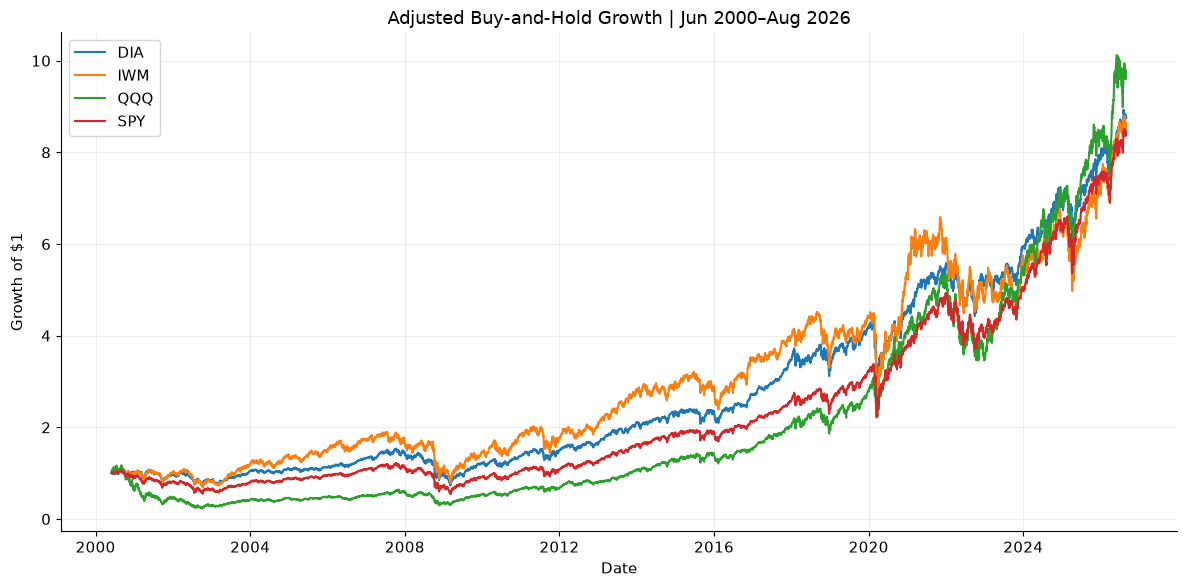

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(etf_daily_growth.index, etf_daily_growth)
plt.legend(etf_daily_growth.columns)
plt.title("Adjusted Buy-and-Hold Growth | Jun 2000–Aug 2026")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.tight_layout()
plt.show()

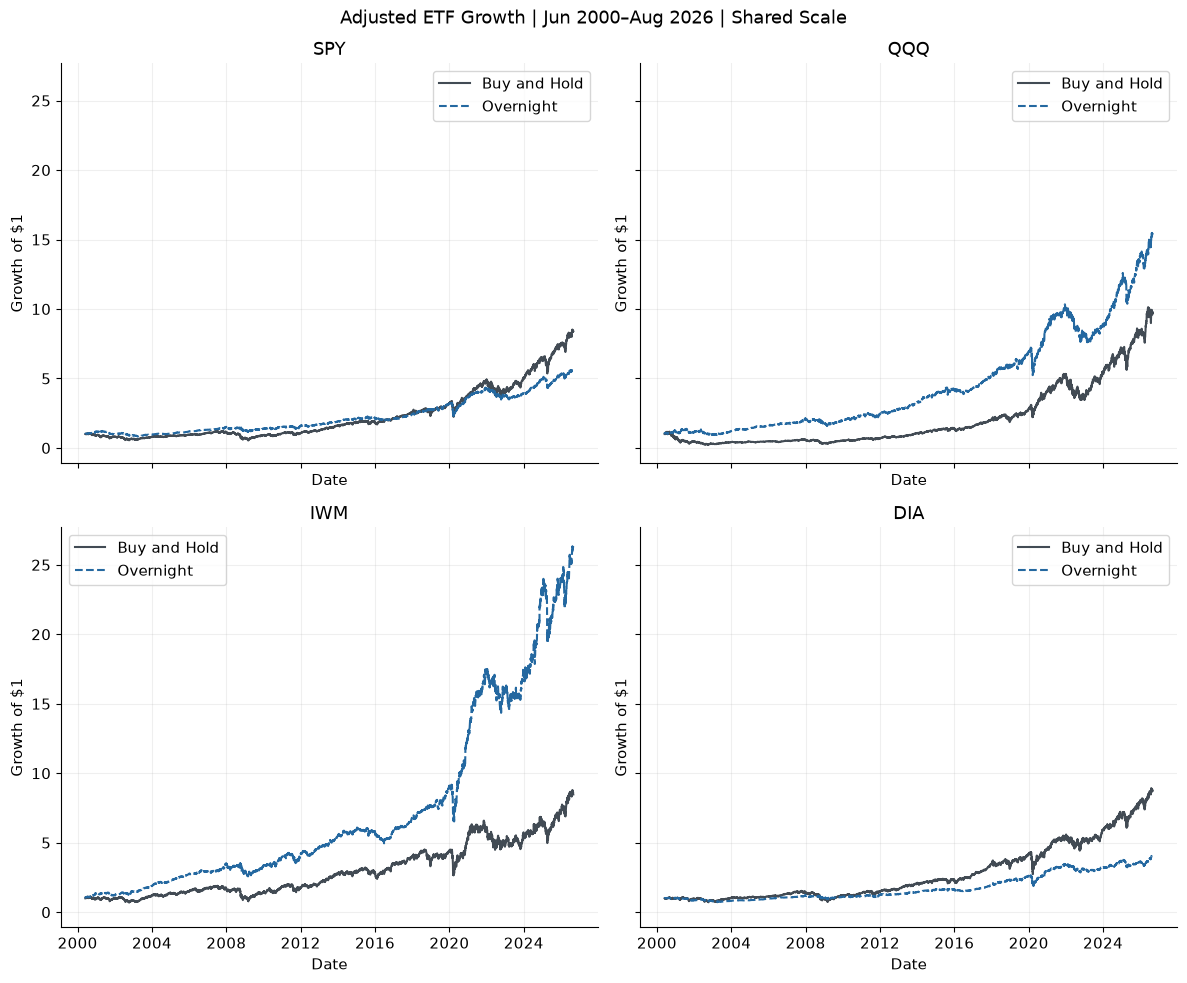

Overnight minus buy-and-hold: percentage-point differences
SPY: -265.25 pp
QQQ: 564.01 pp
IWM: 1777.58 pp
DIA: -470.86 pp


In [16]:
# Compute overnight returns
etf_overnight_returns = etf_data["Open"] / etf_data["Close"].shift(1) - 1
etf_overnight_returns.iloc[0] = 0  # No overnight trade before the first close.
etf_overnight_growth = (1 + etf_overnight_returns).cumprod()

# Plot overnight returns vs benchmark
fig, ax = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

ax[0, 0].plot(etf_daily_growth.index, etf_daily_growth["SPY"], label="Buy and Hold", color=benchmark_color)
ax[0, 0].plot(etf_daily_growth.index, etf_overnight_growth["SPY"], label="Overnight", color=overnight_color, linestyle="--")
ax[0, 0].legend()
ax[0, 0].set_title("SPY")

ax[0, 1].plot(etf_daily_growth.index, etf_daily_growth["QQQ"], label="Buy and Hold", color=benchmark_color)
ax[0, 1].plot(etf_daily_growth.index, etf_overnight_growth["QQQ"], label="Overnight", color=overnight_color, linestyle="--")
ax[0, 1].legend()
ax[0, 1].set_title("QQQ")

ax[1, 0].plot(etf_daily_growth.index, etf_daily_growth["IWM"], label="Buy and Hold", color=benchmark_color)
ax[1, 0].plot(etf_daily_growth.index, etf_overnight_growth["IWM"], label="Overnight", color=overnight_color, linestyle="--")
ax[1, 0].legend()
ax[1, 0].set_title("IWM")

ax[1, 1].plot(etf_daily_growth.index, etf_daily_growth["DIA"], label="Buy and Hold", color=benchmark_color)
ax[1, 1].plot(etf_daily_growth.index, etf_overnight_growth["DIA"], label="Overnight", color=overnight_color, linestyle="--")
ax[1, 1].legend()
ax[1, 1].set_title("DIA")

for subplot in ax.flat:
    subplot.set_xlabel("Date")
    subplot.set_ylabel("Growth of $1")
fig.suptitle("Adjusted ETF Growth | Jun 2000–Aug 2026 | Shared Scale")
plt.tight_layout()
plt.show()

# Terminal cumulative-return differences, in percentage points (not growth multiples).
print("Overnight minus buy-and-hold: percentage-point differences")
print(f"SPY: {100 * (etf_overnight_growth['SPY'].iloc[-1] - etf_daily_growth['SPY'].iloc[-1]):.2f} pp")
print(f"QQQ: {100 * (etf_overnight_growth['QQQ'].iloc[-1] - etf_daily_growth['QQQ'].iloc[-1]):.2f} pp")
print(f"IWM: {100 * (etf_overnight_growth['IWM'].iloc[-1] - etf_daily_growth['IWM'].iloc[-1]):.2f} pp")
print(f"DIA: {100 * (etf_overnight_growth['DIA'].iloc[-1] - etf_daily_growth['DIA'].iloc[-1]):.2f} pp")

Overnight-only performance differs substantially across ETFs. In the adjusted-price sample beginning in June 2000, overnight-only finishes ahead of buy-and-hold for **QQQ and IWM**, but behind for **SPY and DIA**.

| ETF | Overnight minus buy-and-hold cumulative return |
| --- | ---: |
| SPY | −265.25 percentage points |
| QQQ | +564.01 percentage points |
| IWM | +1,777.58 percentage points |
| DIA | −470.86 percentage points |

These figures are differences in cumulative returns, not relative percentage outperformance or annualized returns. IWM has the largest overnight advantage among the ETFs examined, while DIA has the largest shortfall. This indicates that an overnight-only advantage over buy-and-hold is not uniform across these four ETFs. Adding intraday returns helps explain the difference in their compounded outcomes.

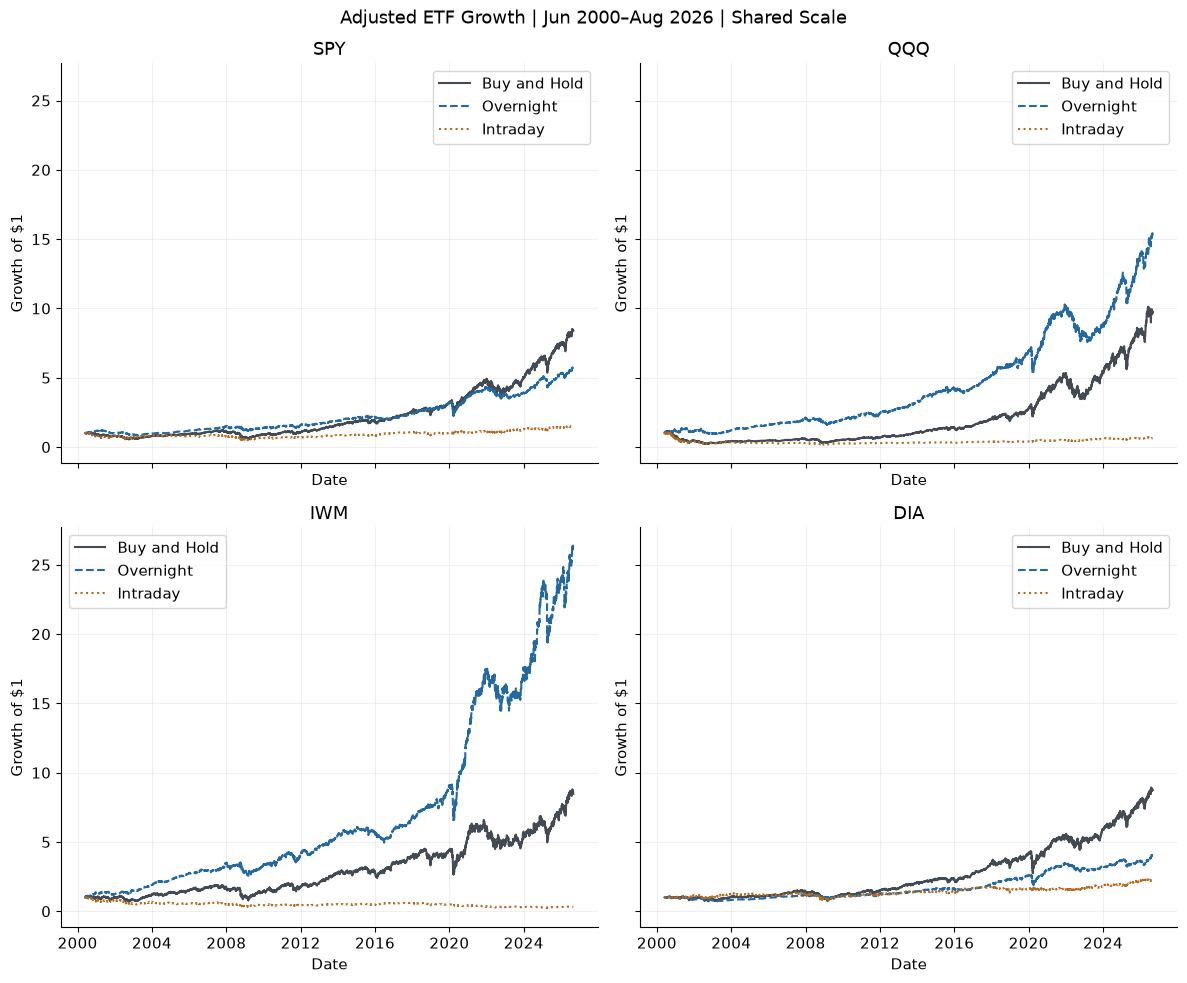

In [17]:
# Compute intraday returns
etf_intraday_returns = etf_data["Close"] / etf_data["Open"] - 1
etf_intraday_returns.iloc[0] = 0  # Align with the first-close baseline.
etf_intraday_growth = (1 + etf_intraday_returns).cumprod()
np.testing.assert_allclose(
    etf_daily_growth, etf_overnight_growth * etf_intraday_growth,
    rtol=1e-10, equal_nan=True,
)

# Plot overnight returns vs intraday vs benchmark
fig, ax = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

ax[0, 0].plot(etf_daily_growth.index, etf_daily_growth["SPY"], label="Buy and Hold", color=benchmark_color)
ax[0, 0].plot(etf_daily_growth.index, etf_overnight_growth["SPY"], label="Overnight", color=overnight_color, linestyle="--")
ax[0, 0].plot(etf_daily_growth.index, etf_intraday_growth["SPY"], label="Intraday", color=intraday_color, linestyle=":")
ax[0, 0].legend()
ax[0, 0].set_title("SPY")

ax[0, 1].plot(etf_daily_growth.index, etf_daily_growth["QQQ"], label="Buy and Hold", color=benchmark_color)
ax[0, 1].plot(etf_daily_growth.index, etf_overnight_growth["QQQ"], label="Overnight", color=overnight_color, linestyle="--")
ax[0, 1].plot(etf_daily_growth.index, etf_intraday_growth["QQQ"], label="Intraday", color=intraday_color, linestyle=":")
ax[0, 1].legend()
ax[0, 1].set_title("QQQ")

ax[1, 0].plot(etf_daily_growth.index, etf_daily_growth["IWM"], label="Buy and Hold", color=benchmark_color)
ax[1, 0].plot(etf_daily_growth.index, etf_overnight_growth["IWM"], label="Overnight", color=overnight_color, linestyle="--")
ax[1, 0].plot(etf_daily_growth.index, etf_intraday_growth["IWM"], label="Intraday", color=intraday_color, linestyle=":")
ax[1, 0].legend()
ax[1, 0].set_title("IWM")

ax[1, 1].plot(etf_daily_growth.index, etf_daily_growth["DIA"], label="Buy and Hold", color=benchmark_color)
ax[1, 1].plot(etf_daily_growth.index, etf_overnight_growth["DIA"], label="Overnight", color=overnight_color, linestyle="--")
ax[1, 1].plot(etf_daily_growth.index, etf_intraday_growth["DIA"], label="Intraday", color=intraday_color, linestyle=":")
ax[1, 1].legend()
ax[1, 1].set_title("DIA")

for subplot in ax.flat:
    subplot.set_xlabel("Date")
    subplot.set_ylabel("Growth of $1")
fig.suptitle("Adjusted ETF Growth | Jun 2000–Aug 2026 | Shared Scale")
plt.tight_layout()
plt.show()

The intraday curves explain why overnight-only beats buy-and-hold for some ETFs but not others. **QQQ and IWM finish with intraday growth below \$1**, so their cumulative intraday losses reduce buy-and-hold wealth relative to overnight-only. **SPY and DIA finish with intraday growth above \$1**, so positive intraday compounding raises buy-and-hold wealth above overnight-only. DIA shows the strongest terminal intraday growth among the four ETFs.

For these aligned price series, buy-and-hold growth equals overnight growth multiplied by intraday growth; the preceding calculation checks this identity. The results establish differences across the selected ETFs, but do not identify whether index weighting, sector composition, or another characteristic causes those differences.

## 4. Are mean overnight returns statistically different from mean intraday returns?

We will use a two-sided paired t-test. Each overnight return is matched with the intraday return on the same date. Define the daily difference as:

$$D_t = R_{\text{overnight},t} - R_{\text{intraday},t}.$$

Our hypotheses are:

$$H_0: \mu_D = 0 \qquad H_a: \mu_D \neq 0.$$

We will use a 5% significance level. This tests the mean difference, not whether the entire distributions or cumulative wealth curves are the same.

In [18]:
paired_test = ttest_rel(returns["OvernightReturn"], returns["IntradayReturn"])
return_difference = returns["OvernightReturn"] - returns["IntradayReturn"]
confidence_interval = paired_test.confidence_interval(0.95)

print(f"Paired observations: {len(returns):,}")
print(f"Mean overnight:  {returns['OvernightReturn'].mean():.4%}")
print(f"Mean intraday:   {returns['IntradayReturn'].mean():.4%}")
print(f"Mean difference: {return_difference.mean():.4%}")
print(f"t-statistic:     {paired_test.statistic:.3f}")
print(f"p-value:         {paired_test.pvalue:.4f}")
print(f"95% CI:          ({confidence_interval.low:.4%}, {confidence_interval.high:.4%})")

Paired observations: 6,704
Mean overnight:  0.0228%
Mean intraday:   0.0092%
Mean difference: 0.0136%
t-statistic:     0.936
p-value:         0.3495
95% CI:          (-0.0149%, 0.0421%)


The p-value is **0.3495**, and the 95% confidence interval for the mean daily difference is **−0.0149% to 0.0421%**. We do not have enough evidence to reject the null hypothesis at the 5% level. This does not prove the means are equal; it means this test does not clearly distinguish them.

The result does not contradict the earlier wealth curves. Arithmetic mean returns and compounded growth answer different questions, and extreme observations can affect the final outcome. We will investigate those observations next. The t-test also does not explicitly account for dependence between days or changing volatility, which would be useful to examine in future work.

## 5. How sensitive is the anomaly to extreme observations?

We will first look at the overnight and intraday return distributions. Then we will examine the top and bottom 1% of overnight returns to see when those observations occur and how much they affect compounded growth.

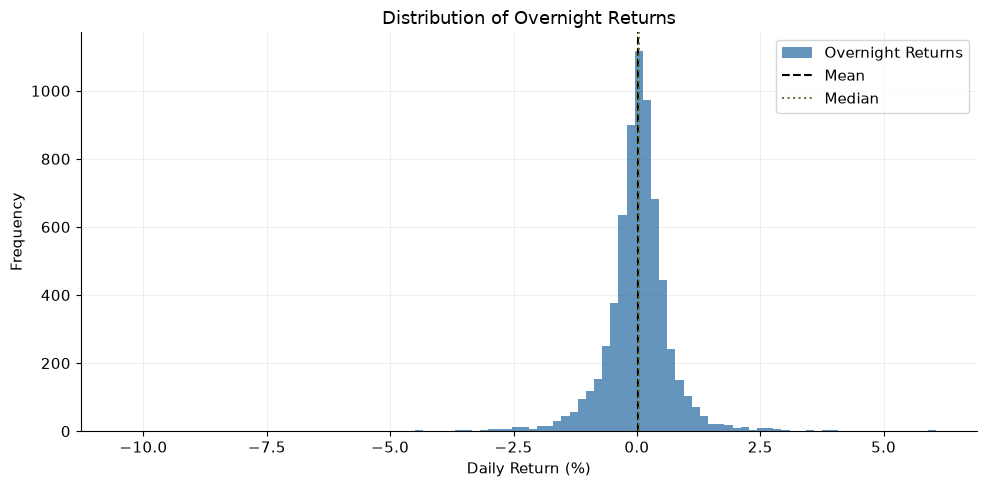

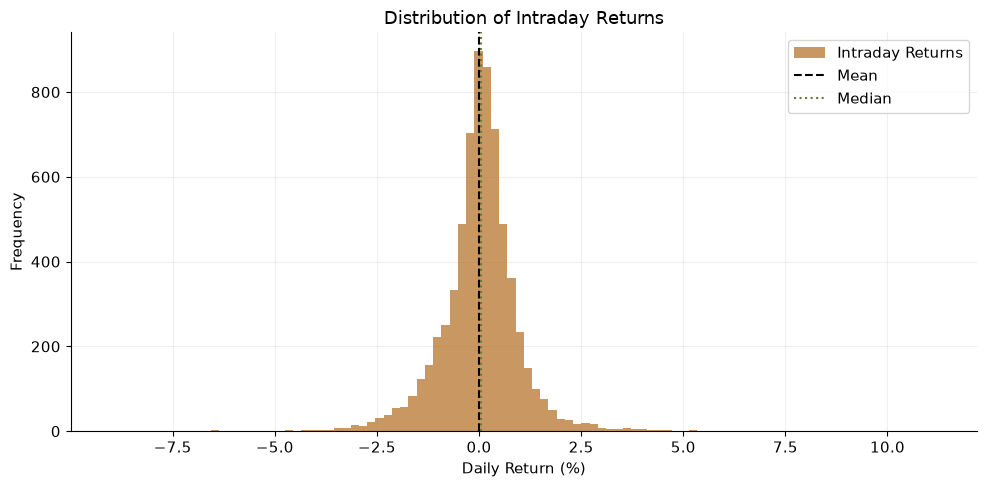

Overnight mean:   0.0228%
Overnight median: 0.0432%
Intraday mean:    0.0092%
Intraday median:  0.0541%
Overnight skew:   -1.252
Intraday skew:    0.079


In [19]:
# Overnight Returns
plt.figure(figsize=(10, 5))
plt.hist(returns["OvernightReturn"] * 100, bins=100, alpha=0.7,
         label="Overnight Returns", color=overnight_color)
plt.axvline(x=returns["OvernightReturn"].mean() * 100, color="black", linestyle="--", label="Mean")
plt.axvline(x=returns["OvernightReturn"].median() * 100, color=filtered_color, linestyle=":", label="Median")
plt.legend()
plt.title("Distribution of Overnight Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Intraday Returns
plt.figure(figsize=(10, 5))
plt.hist(returns["IntradayReturn"] * 100, bins=100, alpha=0.7,
         label="Intraday Returns", color=intraday_color)
plt.axvline(x=returns["IntradayReturn"].mean() * 100, color="black", linestyle="--", label="Mean")
plt.axvline(x=returns["IntradayReturn"].median() * 100, color=filtered_color, linestyle=":", label="Median")
plt.legend()
plt.title("Distribution of Intraday Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Overnight mean:   {returns['OvernightReturn'].mean():.4%}")
print(f"Overnight median: {returns['OvernightReturn'].median():.4%}")
print(f"Intraday mean:    {returns['IntradayReturn'].mean():.4%}")
print(f"Intraday median:  {returns['IntradayReturn'].median():.4%}")
print(f"Overnight skew:   {skew(returns['OvernightReturn'], bias=False):.3f}")
print(f"Intraday skew:    {skew(returns['IntradayReturn'], bias=False):.3f}")

Interestingly, overnight returns have negative skewness of about **−1.25**, consistent with a heavier negative tail. Large negative observations pull the mean below the median. Intraday skewness is close to zero, but that alone does not mean the distribution is normal.

Negative skewness also does not rule out an important contribution from large positive returns. We will examine both tails rather than draw that conclusion from skewness alone.

In [20]:
# Calculate the thresholds once using the full sample.
bottom_threshold = returns["OvernightReturn"].quantile(0.01)
top_threshold = returns["OvernightReturn"].quantile(0.99)
worst_1pct = returns.loc[returns["OvernightReturn"] <= bottom_threshold]

# Use valid return observations as the denominator, including the partial final year.
year_total = returns.groupby(returns.index.year).size()
bottom_counts = worst_1pct.groupby(worst_1pct.index.year).size()
bottom_counts = bottom_counts.reindex(year_total.index, fill_value=0)
bottom_rates = bottom_counts / year_total

bottom_by_year = pd.DataFrame({"Count": bottom_counts, "Rate (%)": bottom_rates * 100})
print("Bottom 1% observations by year (2026 is partial):")
print(bottom_by_year.round(2))

Bottom 1% observations by year (2026 is partial):
      Count  Rate (%)
Date                 
2000      2      0.80
2001      3      1.21
2002      2      0.79
2003      0      0.00
2004      0      0.00
2005      0      0.00
2006      0      0.00
2007      0      0.00
2008     14      5.53
2009      7      2.78
2010      2      0.79
2011      8      3.17
2012      1      0.40
2013      0      0.00
2014      0      0.00
2015      2      0.79
2016      2      0.79
2017      0      0.00
2018      0      0.00
2019      0      0.00
2020     14      5.53
2021      0      0.00
2022      5      1.99
2023      0      0.00
2024      1      0.40
2025      5      2.00
2026      0      0.00


Both 2008 and 2020 have **14 observations** in the full-sample bottom 1%, or **5.53%** of each year's valid overnight returns. These losses are concentrated in certain years rather than spread evenly through the sample.

This is consistent with periods of higher volatility, but we have not formally tested that explanation. A year with no bottom-tail observations is not necessarily a low-risk year. We will now check whether the largest positive returns occur in the same periods.

In [21]:
best_1pct = returns.loc[returns["OvernightReturn"] >= top_threshold]
top_counts = best_1pct.groupby(best_1pct.index.year).size()
top_counts = top_counts.reindex(year_total.index, fill_value=0)
top_rates = top_counts / year_total

top_by_year = pd.DataFrame({"Count": top_counts, "Rate (%)": top_rates * 100})
print("Top 1% observations by year (2026 is partial):")
print(top_by_year.round(2))

Top 1% observations by year (2026 is partial):
      Count  Rate (%)
Date                 
2000      4      1.59
2001      3      1.21
2002      4      1.59
2003      1      0.40
2004      0      0.00
2005      0      0.00
2006      0      0.00
2007      2      0.80
2008     16      6.32
2009      5      1.98
2010      1      0.40
2011      5      1.98
2012      0      0.00
2013      0      0.00
2014      0      0.00
2015      2      0.79
2016      0      0.00
2017      0      0.00
2018      0      0.00
2019      0      0.00
2020     16      6.32
2021      0      0.00
2022      4      1.59
2023      0      0.00
2024      1      0.40
2025      3      1.20
2026      1      0.60


The years with the most extreme losses also contain many of the largest gains. Both 2008 and 2020 have **16 top-tail observations**, or **6.32%** of their valid overnight returns. Avoiding a volatile period could therefore remove valuable positive returns as well as losses.

We will next remove the tails to see how much they affect growth. These thresholds use the whole sample and identify dates with hindsight. This is a sensitivity check, not a trading rule that could have selected those dates in advance.

In [22]:
# Reuse the original overnight wealth rather than calculating it again.
growth_without_top = (1 + returns.loc[
    returns["OvernightReturn"] < top_threshold, "OvernightReturn"
]).prod()

growth_without_bottom = (1 + returns.loc[
    returns["OvernightReturn"] > bottom_threshold, "OvernightReturn"
]).prod()

middle_98 = returns.loc[
    (returns["OvernightReturn"] > bottom_threshold) &
    (returns["OvernightReturn"] < top_threshold), "OvernightReturn"
]
growth_middle = (1 + middle_98).prod()

print(f"Original growth:             {growth['OvernightReturn'].iloc[-1]:.2f}×")
print(f"Growth without top 1%:       {growth_without_top:.2f}×")
print(f"Growth without bottom 1%:    {growth_without_bottom:.2f}×")
print(f"Growth without both tails:   {growth_middle:.2f}×")

Original growth:             3.91×
Growth without top 1%:       0.59×
Growth without bottom 1%:    36.02×
Growth without both tails:   5.46×


Removing the top 1% of overnight returns reduces cumulative growth from **3.91× to 0.59×**, turning the result into a loss. Removing the bottom 1% increases growth to **36.02×**, while removing both tails produces **5.46×**.

Positive tail events matter, but extreme negative observations have an even larger impact in this sensitivity check. Removing observations from the product is equivalent to earning zero on those excluded dates; it does not show an achievable strategy. A potential next step is to investigate whether a rule using information available beforehand can reduce those losses without giving up too many gains.

## 6. Has the anomaly changed over time?

We will plot the three-year rolling mean of the overnight-minus-intraday difference. Using 756 trading observations gives us a broader view of how the average difference changes over time.

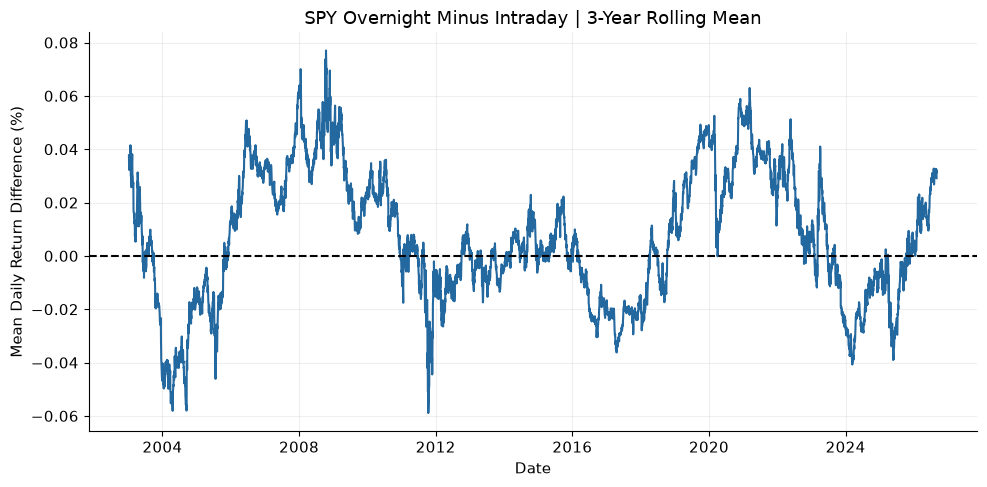

In [23]:
rolling_3y_mean = return_difference.rolling(trading_days * 3).mean()

plt.figure(figsize=(10, 5))
plt.plot(rolling_3y_mean.index, rolling_3y_mean * 100, color=overnight_color)
plt.title("SPY Overnight Minus Intraday | 3-Year Rolling Mean")
plt.axhline(0, color="black", linestyle="--")
plt.ylabel("Mean Daily Return Difference (%)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

The three-year rolling mean changes sign several times, so the overnight advantage does not have a constant magnitude. Some periods favor overnight returns, while others show little advantage or favor intraday returns.

We will summarize five complete calendar buckets: **2000–2004, 2005–2009, 2010–2014, 2015–2019, and 2020–2024**. We exclude 2025–2026 from this comparison because that five-year bucket is incomplete, but keep those observations in the full-sample analysis.

In [24]:
buckets = returns.loc[returns.index.year < 2025].copy()
buckets["PeriodStart"] = (buckets.index.year // 5) * 5

bucket_stats = buckets.groupby("PeriodStart").agg(
    OvernightMean=("OvernightReturn", "mean"),
    IntradayMean=("IntradayReturn", "mean"),
)
bucket_stats["Difference"] = bucket_stats["OvernightMean"] - bucket_stats["IntradayMean"]

print("Mean daily returns and differences (%):")
print((bucket_stats * 100).round(4))

Mean daily returns and differences (%):
             OvernightMean  IntradayMean  Difference
PeriodStart                                         
2000                0.0048       -0.0105      0.0152
2005                0.0199       -0.0157      0.0356
2010                0.0269        0.0264      0.0005
2015                0.0259        0.0134      0.0124
2020                0.0317        0.0243      0.0075


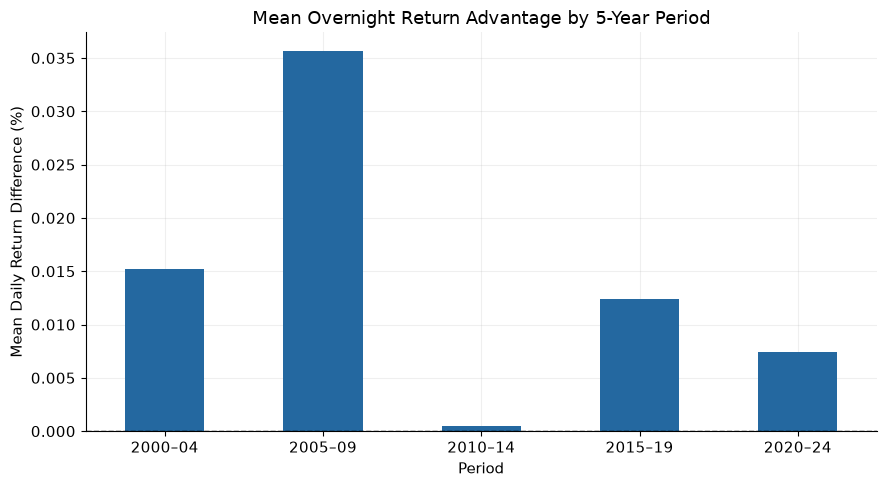

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

(bucket_stats["Difference"] * 100).plot(
    kind="bar",
    ax=ax, color=overnight_color
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set_title("Mean Overnight Return Advantage by 5-Year Period")
ax.set_xlabel("Period")
ax.set_ylabel("Mean Daily Return Difference (%)")

ax.set_xticklabels([
    "2000–04",
    "2005–09",
    "2010–14",
    "2015–19",
    "2020–24"
], rotation=0)

plt.tight_layout()
plt.show()

All five buckets have a positive sample mean difference. The greatest difference is in **2005–2009**, and the smallest is in **2010–2014**, where the two means are close.

This does not establish that the strategy is a dependable opportunity for long-term investors. We will run the same paired t-test within each bucket to check how much statistical evidence supports the observed differences.

In [26]:
bucket_rows = []

for period, group in buckets.groupby("PeriodStart"):
    t_stat, p_value = ttest_rel(group["OvernightReturn"], group["IntradayReturn"])
    bucket_rows.append({
        "Period": f"{period}–{period + 4}",
        "Observations": len(group),
        "Mean difference (%)": bucket_stats.loc[period, "Difference"] * 100,
        "t-statistic": t_stat,
        "p-value": p_value,
    })

bucket_tests = pd.DataFrame(bucket_rows)
print(bucket_tests.round(4).to_string(index=False))

   Period  Observations  Mean difference (%)  t-statistic  p-value
2000–2004          1255               0.0152       0.3913   0.6957
2005–2009          1259               0.0356       0.8953   0.3708
2010–2014          1258               0.0005       0.0181   0.9855
2015–2019          1258               0.0124       0.5132   0.6079
2020–2024          1258               0.0075       0.2122   0.8320


All five p-values are above 0.05, so none of the periods provides enough evidence to reject a zero mean difference. The bar chart shows positive sample averages, but the tests do not establish a consistent population mean advantage.

These are exploratory period comparisons, with no adjustment for testing several periods. The cumulative growth pattern remains worth investigating, but it should not be treated as proof of a stable daily premium.

## 7. Can an EMA filter improve the overnight strategy?

The tail analysis suggests a question worth testing: can a simple trend filter reduce exposure to large negative overnight moves without removing too many positive ones? We will hold overnight only when the previous close is above its exponential moving average (EMA).

We will begin with a 200-day EMA over the full sample, then explore EMA lengths using **2000–2017 as training data** and **2018–August 2026 as the historical test period**. This is a hypothesis about improving the risk profile, not a proven explanation for the anomaly.

For the return ending at today's open, the signal uses yesterday's close and yesterday's EMA. The simulation still assumes we can enter at the same closing price used to form that signal. A practical strategy would need a signal available before the order cutoff and a realistic fill price. Idle cash earns zero.

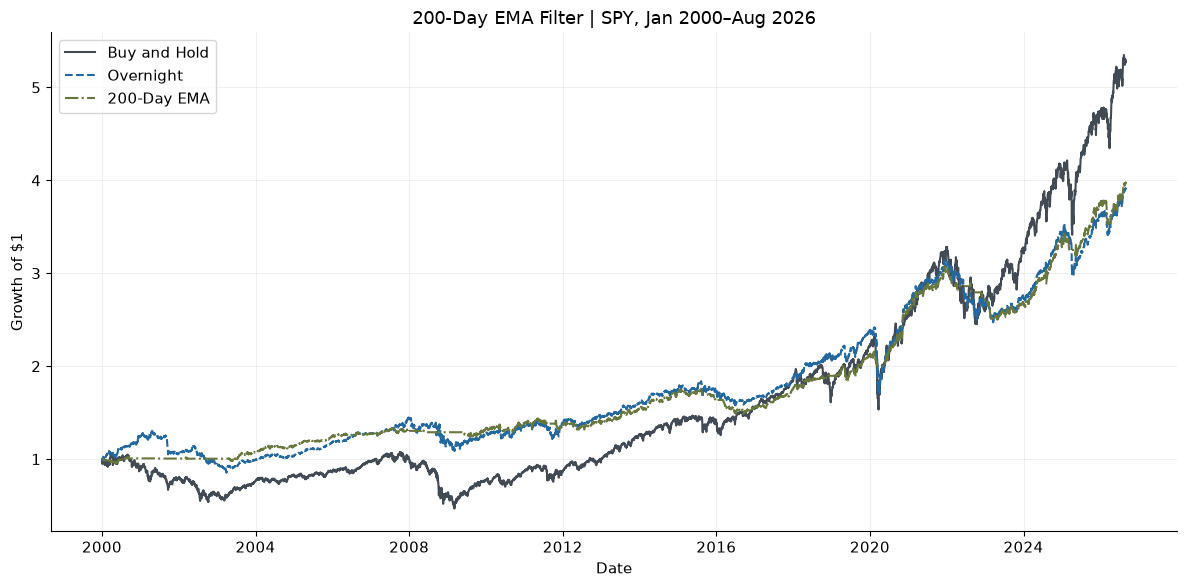

200-day EMA final wealth: $3.97
Overnight final wealth:   $3.91


In [27]:
spy["EMA200"] = spy["Close"].ewm(span=200, adjust=False).mean()
spy["EMA200Signal"] = spy["Close"].shift(1) > spy["EMA200"].shift(1)
spy["EMA200Return"] = spy["OvernightReturn"].where(spy["EMA200Signal"], 0)
growth["EMA200Return"] = (1 + spy["EMA200Return"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(growth.index, growth["DailyReturn"], label="Buy and Hold", color=benchmark_color)
plt.plot(growth.index, growth["OvernightReturn"], label="Overnight", color=overnight_color, linestyle="--")
plt.plot(growth.index, growth["EMA200Return"], label="200-Day EMA", color=filtered_color, linestyle="-.")
plt.title("200-Day EMA Filter | SPY, Jan 2000–Aug 2026")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

print(f"200-day EMA final wealth: ${growth['EMA200Return'].iloc[-1]:.2f}")
print(f"Overnight final wealth:   ${growth['OvernightReturn'].iloc[-1]:.2f}")

The 200-day filter finishes slightly above the unfiltered overnight strategy: about **\$3.97 versus \$3.91** per initial \$1. Both finish below buy-and-hold. This is only a small terminal-wealth improvement in the full sample, so we should not assume the filter will improve every measure of performance.

We will now explore spans from 10 to 999 days using training data only. We will select by final growth and display Sharpe as additional context. Searching 990 candidates creates a risk of fitting historical noise, and the EMA also starts from the first available close without a separate warm-up period.

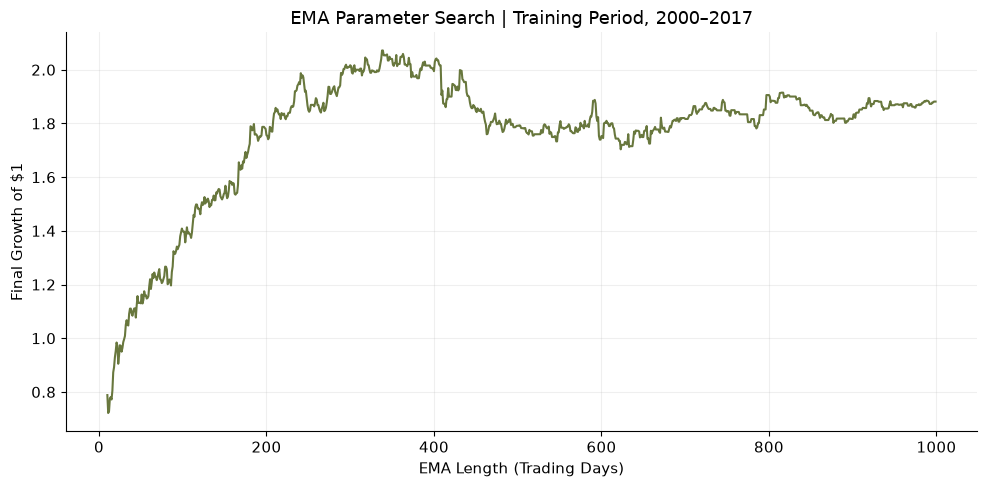

Best training result by final growth:
EMA           338.000000
Growth          2.071821
MeanReturn      0.000168
Sharpe          0.716476
Name: 328, dtype: float64


In [28]:
train = spy.loc[:train_end].copy()
ema_rows = []

for span in range(10, 1000):
    ema = train["Close"].ewm(span=span, adjust=False).mean()
    signal = train["Close"].shift(1) > ema.shift(1)
    filtered_returns = train["OvernightReturn"].where(signal, 0).iloc[1:]

    final_growth = (1 + filtered_returns).prod()
    mean_return = filtered_returns.mean()
    volatility = filtered_returns.std(ddof=1)
    sharpe = mean_return / volatility * np.sqrt(trading_days) if volatility > 0 else np.nan

    ema_rows.append({
        "EMA": span,
        "Growth": final_growth,
        "MeanReturn": mean_return,
        "Sharpe": sharpe,
    })

ema_results = pd.DataFrame(ema_rows)

plt.figure(figsize=(10, 5))
plt.plot(ema_results["EMA"], ema_results["Growth"], color=filtered_color)
plt.xlabel("EMA Length (Trading Days)")
plt.ylabel("Final Growth of $1")
plt.title("EMA Parameter Search | Training Period, 2000–2017")
plt.tight_layout()
plt.show()

best_ema = ema_results.loc[ema_results["Growth"].idxmax()]
print("Best training result by final growth:")
print(best_ema.round(6))

The best training growth occurs at an EMA length of **338 days**. We will retain the original rounded choice of **340 days**, set as `ema_span` near the top of the notebook. That is a nearby choice, not the exact maximizing parameter.

We will calculate the EMA using all the available price history before selecting the test dates. This lets the EMA carry its history into 2018 instead of restarting at the test boundary. The same 340-day EMA will determine the signal, filtered returns, and growth curve.

The test period has already been examined during this project, so this is a historical holdout rather than untouched future evidence. We will not choose another EMA based on its test outcome.

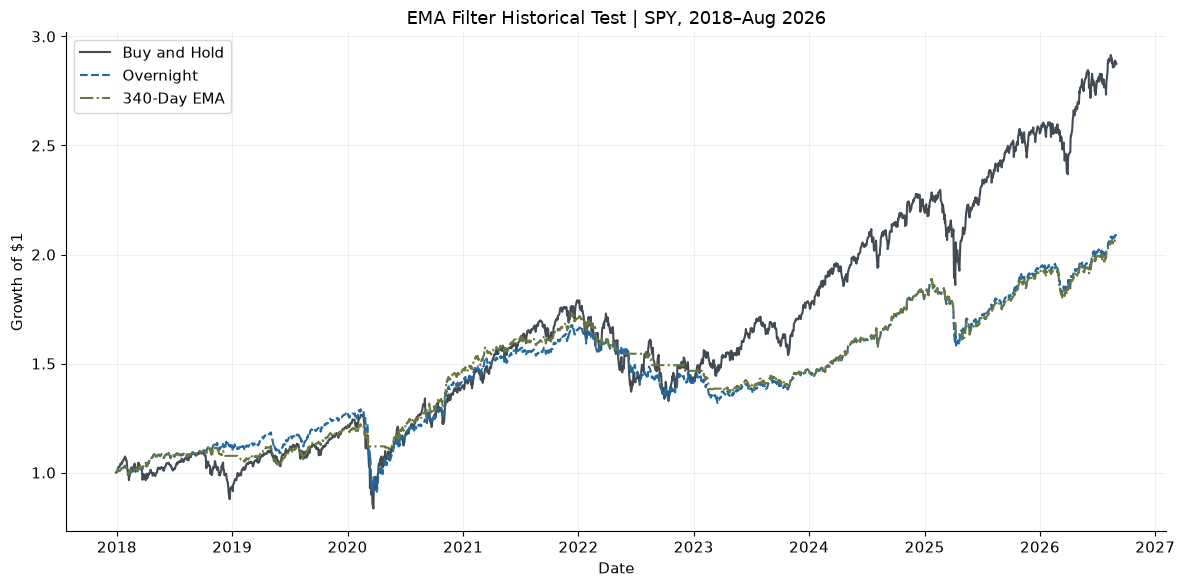

                 Final wealth ($)  Sharpe  Maximum drawdown (%)
DailyReturn                2.8744  0.7351               34.1047
OvernightReturn            2.0846  0.7533               29.4135
FilteredReturn             2.0651  1.0278               20.9138
Relative terminal-wealth difference versus overnight-only: -0.93%
Filtered mean daily return: 0.0348%
Share of test dates with an overnight position: 85.9%


In [29]:
# Compute the selected EMA before slicing so the test period retains prior history.
spy["SelectedEMA"] = spy["Close"].ewm(span=ema_span, adjust=False).mean()
spy["FilteredSignal"] = spy["Close"].shift(1) > spy["SelectedEMA"].shift(1)
spy["FilteredReturn"] = spy["OvernightReturn"].where(spy["FilteredSignal"], 0)
test = spy.loc[test_start:].copy()

# Rebase each test strategy to $1 immediately before the first test return.
test_growth = (1 + test[["DailyReturn", "OvernightReturn", "FilteredReturn"]]).cumprod()
test_growth.loc[train.index[-1]] = 1
test_growth = test_growth.sort_index()

plt.figure(figsize=(12, 6))
plt.plot(test_growth.index, test_growth["DailyReturn"], label="Buy and Hold", color=benchmark_color)
plt.plot(test_growth.index, test_growth["OvernightReturn"], label="Overnight", color=overnight_color, linestyle="--")
plt.plot(test_growth.index, test_growth["FilteredReturn"], label=f"{ema_span}-Day EMA", color=filtered_color, linestyle="-.")
plt.title("EMA Filter Historical Test | SPY, 2018–Aug 2026")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

test_sharpe = (
    test[["DailyReturn", "OvernightReturn", "FilteredReturn"]].mean() /
    test[["DailyReturn", "OvernightReturn", "FilteredReturn"]].std(ddof=1) * np.sqrt(trading_days)
)
# Run the same drawdown function on each strategy column.
test_drawdown = test_growth.apply(drawdowns)
test_summary = pd.DataFrame({
    "Final wealth ($)": test_growth.iloc[-1],
    "Sharpe": test_sharpe,
    "Maximum drawdown (%)": test_drawdown.max() * 100,
})
print(test_summary.round(4))

# Compare the actual filtered strategy with overnight-only, not buy-and-hold.
wealth_difference = test_growth["FilteredReturn"].iloc[-1] / test_growth["OvernightReturn"].iloc[-1] - 1
print(f"Relative terminal-wealth difference versus overnight-only: {wealth_difference:+.2%}")
print(f"Filtered mean daily return: {test['FilteredReturn'].mean():.4%}")
print(f"Share of test dates with an overnight position: {test['FilteredSignal'].mean():.1%}")

The corrected 340-day EMA strategy turns \$1 into about **\$2.0651**, compared with **\$2.0846** for overnight-only and **\$2.8744** for buy-and-hold. Its terminal wealth is **0.93% lower** than overnight-only, so this test does not show a return improvement.

The risk profile does improve: the filtered Sharpe ratio is **1.03 versus 0.75**, and maximum drawdown is **20.91% versus 29.41%** for overnight-only. The strategy holds a position on about **85.9%** of test dates. This makes the filter more interesting as a way to manage exposure than as a way to increase final wealth.

These are descriptive comparisons, not significance tests of the risk metrics. Costs and realistic execution could change the results. The original 37% claim did not measure the filter's improvement: it compared buy-and-hold with overnight-only while the displayed filter still used the 200-day rule. Both issues are corrected here.

## Conclusion

### Summary of findings

The overnight pattern is visible in this sample. About **81.95% of SPY's cumulative log price return** occurred overnight, and overnight-only had a higher historical Sharpe ratio and smaller maximum drawdown than buy-and-hold. However, buy-and-hold still finished with more unlevered wealth.

The pattern was not identical across ETFs. Overnight-only beat buy-and-hold for QQQ and IWM, but not SPY or DIA, in the adjusted-price comparison. Extreme observations also had a large effect: removing the top 1% of SPY overnight returns changed growth from 3.91× to 0.59×.

The statistical evidence was less clear. The full-sample paired test had a **p-value of 0.3495**, and none of the five-year buckets was significant at the 5% level. Finally, the corrected 340-day EMA test improved the historical Sharpe ratio and drawdown but produced **0.93% less terminal wealth** than overnight-only.

### Interpretation

The main takeaway is that a strong-looking cumulative return pattern does not automatically mean a reliable trading edge. Compounding, the distribution of returns, and a few extreme observations all matter. This analysis describes the historical outcome, but it does not establish why the anomaly exists or whether it will continue.

The EMA filter is worth investigating as a risk-management idea. In the test period, it reduced volatility and drawdown without materially improving final wealth. That is a useful distinction: improving the risk profile and improving returns are separate goals.

### What could be worked on next?

- **Use the same price basis throughout.** Repeat the main SPY analysis with adjusted prices and examine dividend treatment so the results can be compared more directly across sections.
- **Add realistic trading assumptions.** Include spreads, commissions, slippage, returns on idle cash, and financing for leveraged exposure. Test a signal that can be calculated before the closing order cutoff.
- **Test the filter on new data.** Use walk-forward testing, where the EMA is selected on an earlier period and then evaluated on the next period. Compare nearby EMA lengths and other assets instead of relying on one best parameter.
- **Check uncertainty more carefully.** Use methods that allow related observations across days, such as a block bootstrap, and examine uncertainty in the Sharpe comparisons.
- **Look at what the filter misses.** Compare the large losses it avoids with the large positive moves it gives up. This would help explain when the filter helps and when it hurts.

Overall, the results support further investigation of overnight exposure and simple risk filters. They do not yet establish a proven excess-return strategy.
